# Usage example for `framework.py`

In this notebook, we show how to run our system in this friendly interface. Steps to run including:
1. Load and convert dBZ data into 2D `np.ndarray` data; each pixel must present exactly dBZ value at that specific location.
2. Prepare basic information:
    - `dbz_threshold`: a binary threshold to classify storm regions.
    - `maximum_velocity`: a real constraint for ensuring matching is performed within some limited velocity of storm. This must be depend on the resolution of the map with respect to the realistic data.
    - For each image, user need to providing a reference time so that the forecast result is well-aligned.

## 1. Load library and load data

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import time
import sys

from tqdm import tqdm
from datetime import datetime

## Load Dataset into 2D numpy arrays, presented dBZ value

In [2]:
from src.preprocessing import read_numpy_grid

DATASET = "KARX"
SOURCE_PATH = f"data/numpy_grid/{DATASET}"

img_paths = [os.path.join(SOURCE_PATH, img_name) for img_name in sorted(os.listdir(SOURCE_PATH)) if img_name.endswith('.npy')]

dbz_maps: list[tuple[np.ndarray, datetime]] = []

for path in tqdm(img_paths, desc="Processing images and detecting storms"):
    file_name = path.split("/")[-1].split(".")[0]

    # Prepare the time frame for each image, which is used for storm tracking and forecasting
    time_frame = datetime.strptime(file_name[4:19], "%Y%m%d_%H%M%S")
    img = read_numpy_grid(path)
    dbz_maps.append((img, time_frame))

print(f"Number of frames: {len(dbz_maps)} | Shape of each frame: {dbz_maps[0][0].shape}")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



Processing images and detecting storms: 100%|██████████| 93/93 [00:00<00:00, 362.14it/s]

Number of frames: 93 | Shape of each frame: (901, 901)


## Visualize how a dBZ map look like

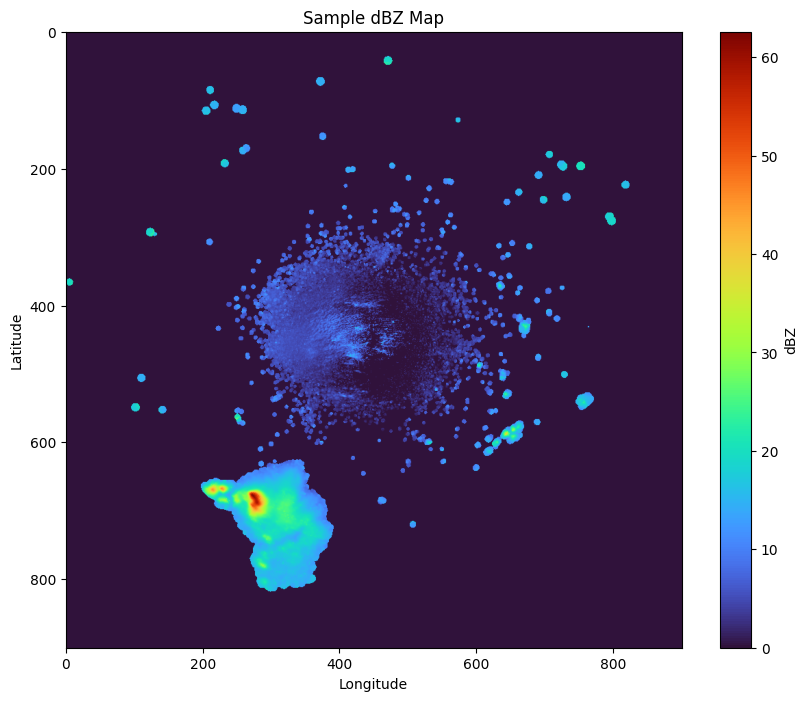

In [20]:
sample_dbz_maps = dbz_maps[0][0]

# Mask negative reflectivity values to 0 so visualization only shows valid dBZ values
sample_dbz_maps = np.clip(sample_dbz_maps, 0, None)

plt.figure(figsize=(10, 8))
im = plt.imshow(sample_dbz_maps, cmap='turbo', vmin=0, vmax=sample_dbz_maps.max())
plt.colorbar(im, label='dBZ')
plt.title('Sample dBZ Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

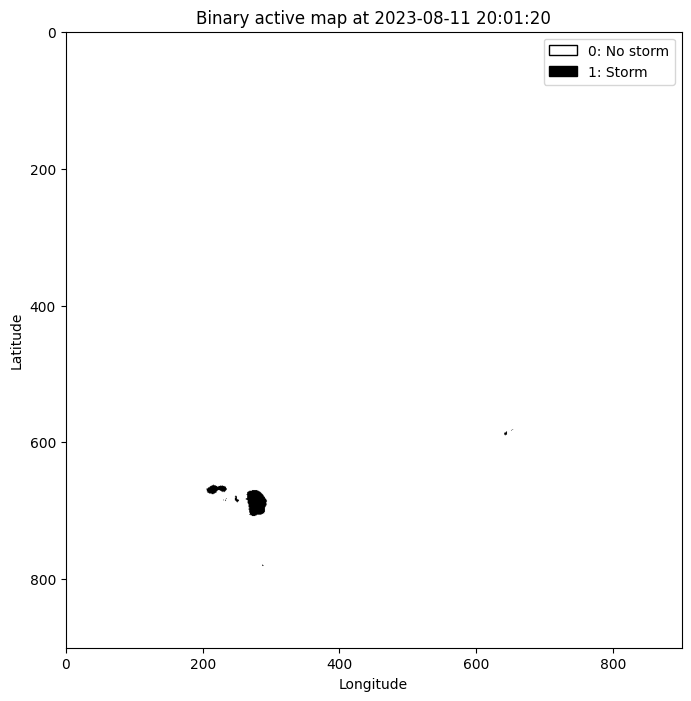

In [22]:
active_map = sample_dbz_maps >= 30  # Example threshold for active storms (dBZ > 30)

plt.figure(figsize=(10, 8))
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['white', 'black'])
plt.imshow(active_map, cmap=cmap, vmin=0, vmax=1)

# Add legend for binary labels instead of a colorbar
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='0: No storm'),
    Patch(facecolor='black', edgecolor='black', label='1: Storm'),
]
plt.legend(handles=legend_elements, loc='upper right')

plt.title(f"Binary active map at {dbz_maps[0][1].strftime('%Y-%m-%d %H:%M:%S')}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## 2. Sample processing model

In [3]:
from framework import SimpleInterfacePrecipitationModel

model_controller = SimpleInterfacePrecipitationModel(
    dbz_threshold=35,
    max_velocity=100,           # This is used for resolution of NEXRAD data
    filter_area=10,             # Skip those small regions that are likely noise
)

model_controller.print_maps()

--------------------
Printing 0 storms maps in the model history:
--------------------


### Processing new map

In [4]:
maps = dbz_maps[:10]  # Process only the first 10 frames for demonstration

for idx, (dbz_map, time_frame) in tqdm(list(enumerate(maps))):
    storms_map = model_controller.process_radar_image(dbz_map, time_frame)

model_controller.print_maps()

100%|██████████| 10/10 [00:03<00:00,  2.96it/s]

--------------------
Printing 10 storms maps in the model history:
	Map [0]: Time Frame = 2023-08-11 20:01:20, Number of Storms = 3
	Map [1]: Time Frame = 2023-08-11 20:05:42, Number of Storms = 3
	Map [2]: Time Frame = 2023-08-11 20:10:03, Number of Storms = 3
	Map [3]: Time Frame = 2023-08-11 20:14:24, Number of Storms = 2
	Map [4]: Time Frame = 2023-08-11 20:18:44, Number of Storms = 3
	Map [5]: Time Frame = 2023-08-11 20:22:56, Number of Storms = 2
	Map [6]: Time Frame = 2023-08-11 20:27:08, Number of Storms = 2
	Map [7]: Time Frame = 2023-08-11 20:31:20, Number of Storms = 4
	Map [8]: Time Frame = 2023-08-11 20:35:32, Number of Storms = 4
	Map [9]: Time Frame = 2023-08-11 20:44:10, Number of Storms = 9
--------------------


### Perform nowcasting

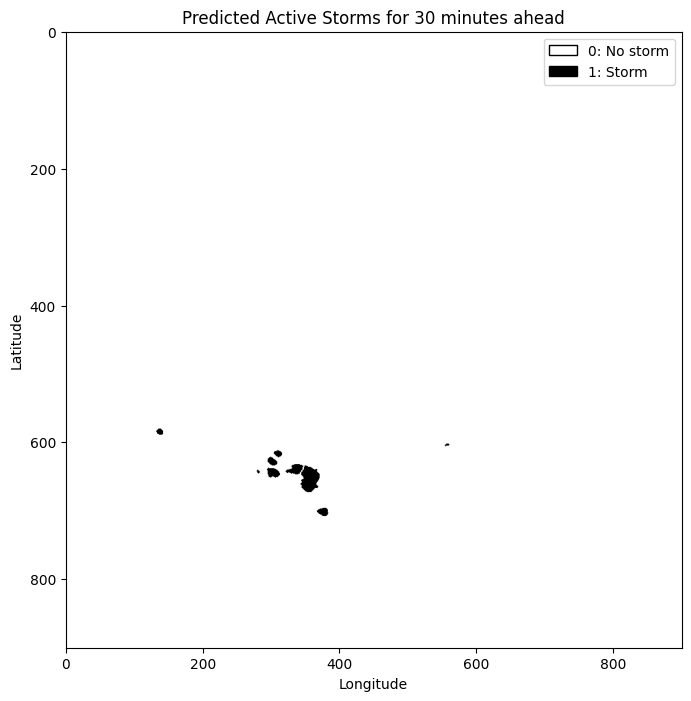

In [12]:
FORECAST_TIME = 30 * 60  # seconds
predicted_map = model_controller.forecast(lead_time=FORECAST_TIME)

# Visualize the predicted map as binary mask
plt.figure(figsize=(10, 8))
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['white', 'black'])
plt.imshow(predicted_map, cmap=cmap, vmin=0, vmax=1)

# Add legend for binary labels instead of a colorbar
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='0: No storm'),
    Patch(facecolor='black', edgecolor='black', label='1: Storm'),
]
plt.legend(handles=legend_elements, loc='upper right')

plt.title(f"Predicted Active Storms for {FORECAST_TIME // 60} minutes ahead")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()